# 🚀 Spaceship Titanic - Exploratory Data Analysis & Visualizations

This notebook conducts a comprehensive data exploration and visualization of the **Spaceship Titanic** dataset to reveal the key patterns, relationships and feature distributions that determine whether a passenger was **Transported** to an alternate dimension.

## Setup & Import Libraries

In [1]:
from src import DatasetVisualizer
from src import SpaceShipDataset

print("Libraries loaded successfully!")

/Users/fabioschiliro/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded successfully!


## Load Dataset

In [2]:
dataset_path = 'dataset'

sd = SpaceShipDataset(dataset_path)
sd.print_stats()

The dataset has been found in 'dataset'!
+====================================================================================================================================================================================================================================+
|                                                                                                     SpaceShip Titanic Dataset                                                                                                      |
+====================================================================================================================================================================================================================================+
| Train Data Size: 8,693 rows                                                                                                                                                                                                        |
| Train Features (20): PassengerId,

In [3]:
sd.train.head(5)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Cabin_Deck,Cabin_Num,Cabin_Side,Group_Id,Group_Size,Is_Solo
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,0,P,1,1,True
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,0,S,2,1,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,0,S,3,2,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,0,S,3,2,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,1,S,4,1,True


## Dataset Info & Summary Statistics

The dataset has the following fields:

- **PassengerId**: A unique ID for each passenger. Each ID takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.

- **HomePlanet**: The planet the passenger departed from, typically their planet of permanent residence.

- **CryoSleep**: Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.

- **Cabin**_ The cabin number where the passenger is staying. Takes the form deck / num / side, where side can be either P for Port or S for Starboard.

- **Destination**: The planet the passenger will be debarking to.

- **Age**: The age of the passenger.

- **VIP**: Whether the passenger has paid for special VIP service during the voyage.

- **RoomService, FoodCourt, ShoppingMall, Spa, VRDeck**: Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.

- **Name**: The first and last names of the passenger.

- **Transported**: Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

In [14]:
sd.show_info(split = 'train')


                          🚀 TRAIN DATASET — INFO & STATISTICAL SUMMARY                         
                            Total Rows: 8,693  |  Total Columns: 20                            



                              📋 Feature Overview & Missing Values                              


     Feature   Dtype Non-Null Count Missing Count Missing (%) Unique Values    Sample Value
 PassengerId     str          8,693             0       0.00%         8,693         0001_01
  HomePlanet     str          8,492           201       2.31%             3          Europa
   CryoSleep  object          8,476           217       2.50%             2           False
       Cabin     str          8,494           199       2.29%         6,560           B/0/P
 Destination     str          8,511           182       2.09%             3     TRAPPIST-1e
         Age float64          8,514           179       2.06%            80            39.0
         VIP  object          8,490           203       2.34% 

In [4]:
# Create the visualzier to analyze all the following sections
vzr = DatasetVisualizer(sd.train)

### Missing Values Analysis

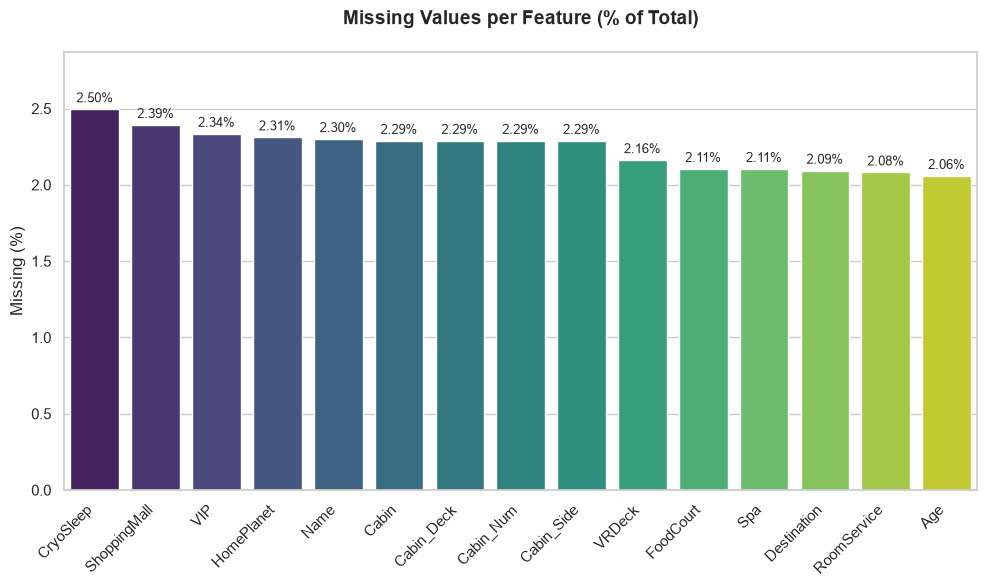

In [5]:
vzr.visualize_missing_values()

### Target Variable Balance

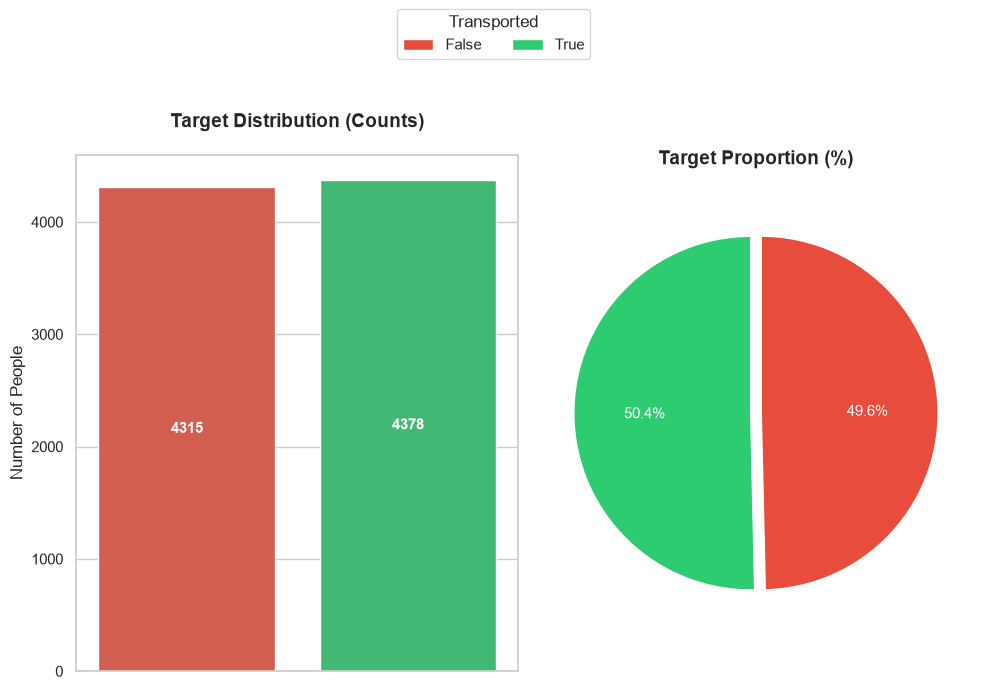

In [5]:
vzr.visualize_target_balance()

### Categorical Features vs Target

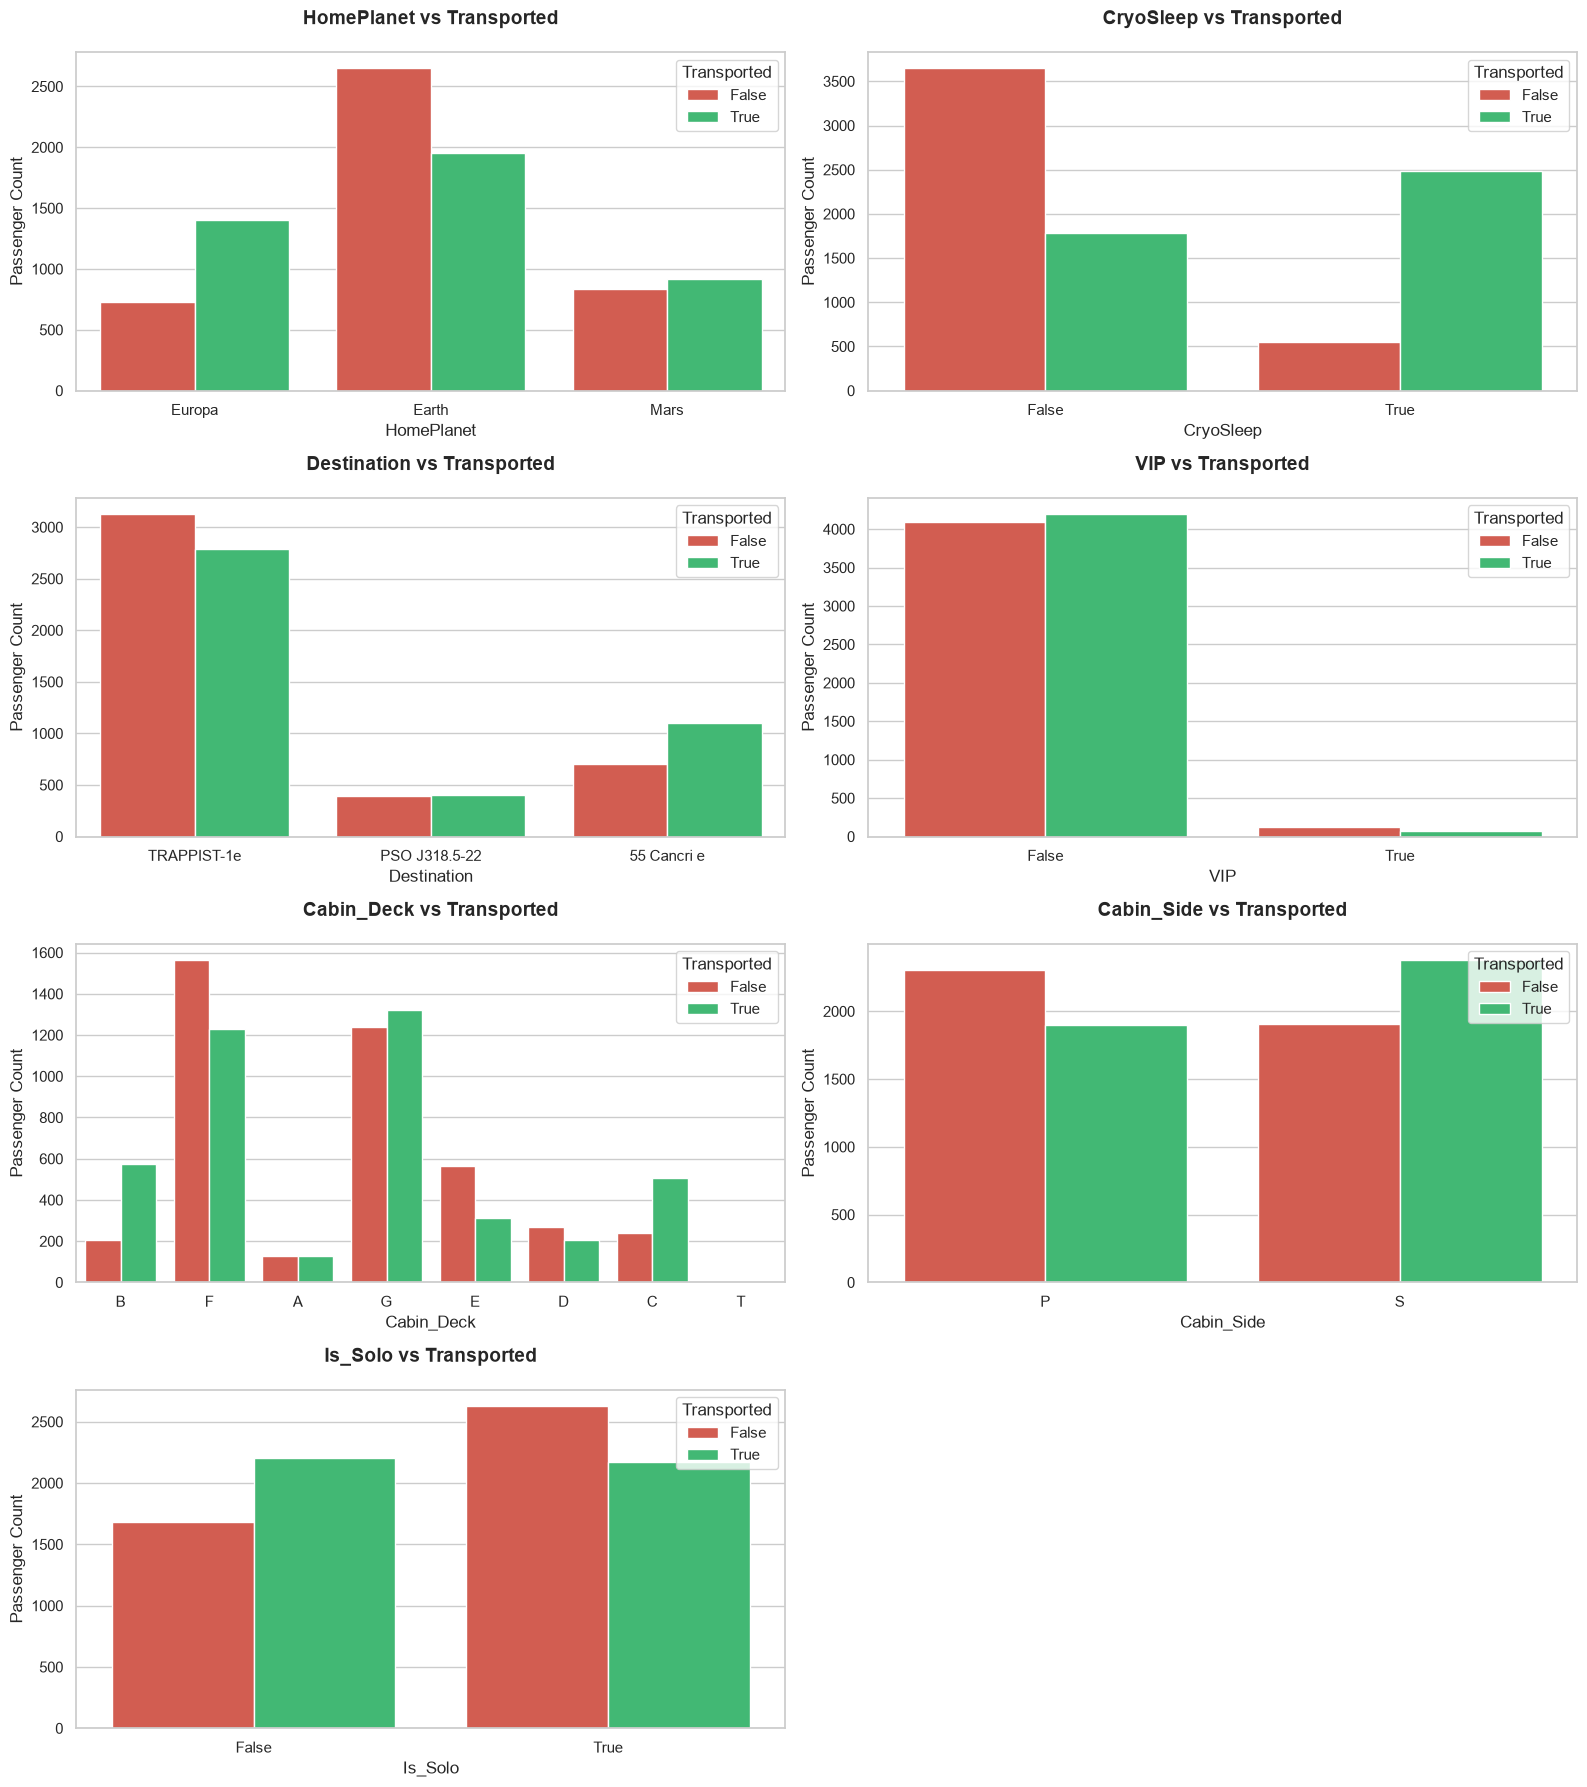

In [8]:
vzr.visualize_categorical_vs_target()

### Transported Rates for Categorical Features

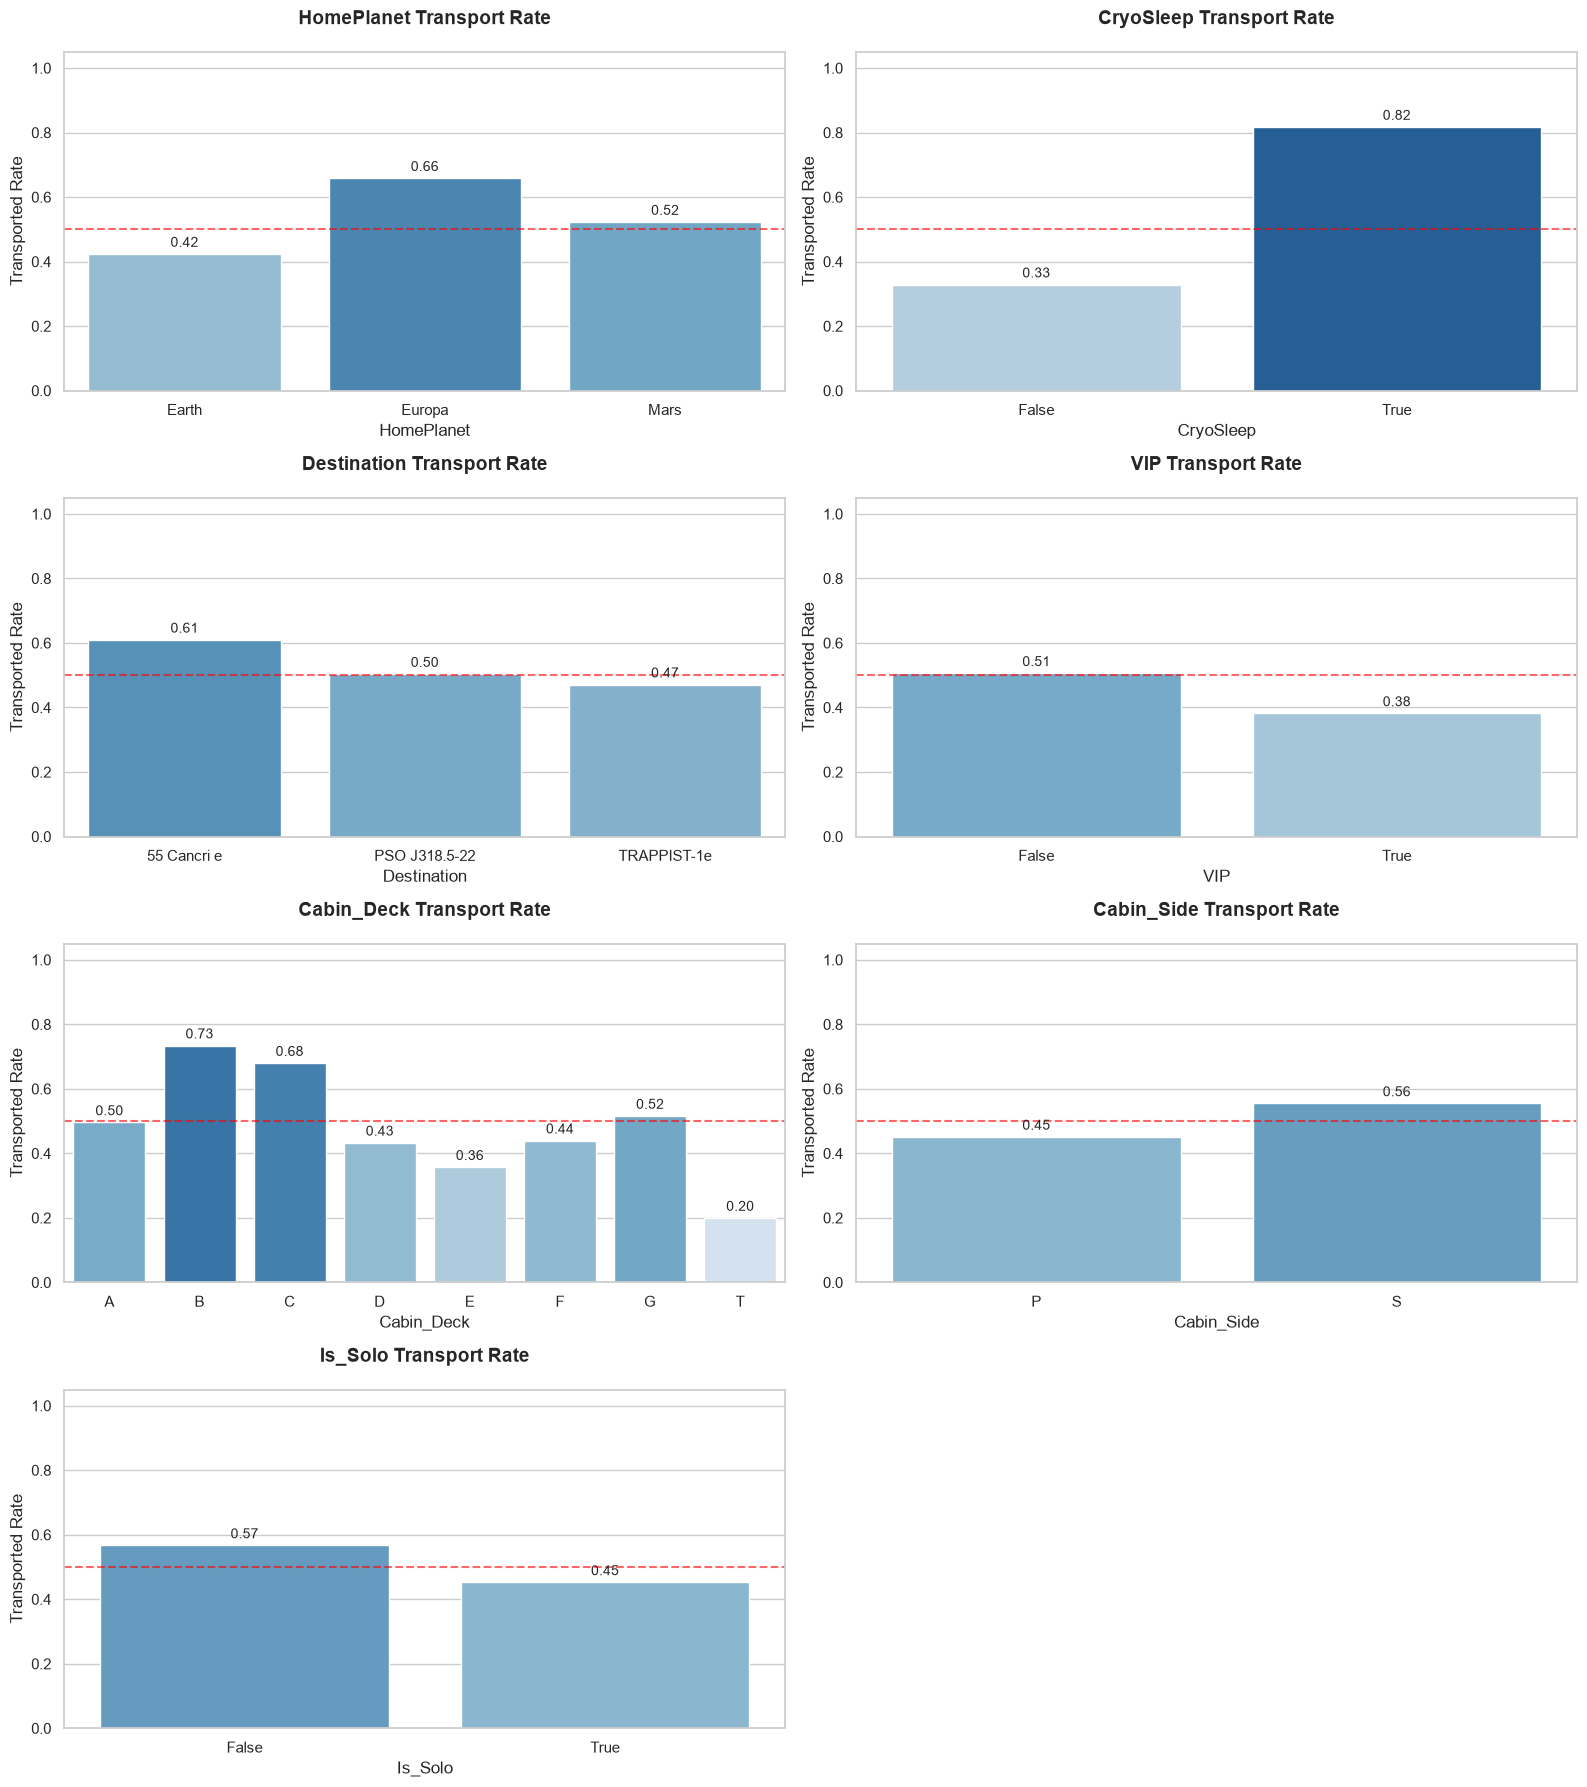

In [5]:
vzr.visualize_categorical_transport_rates()

### Age Distribution Analysis

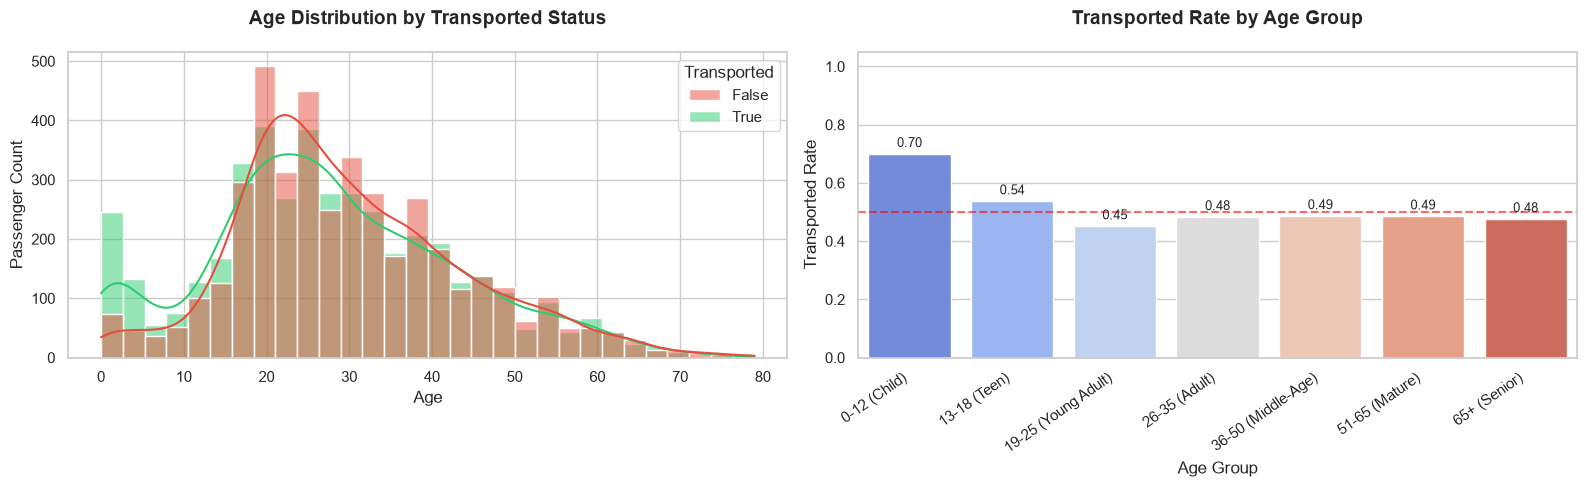

In [6]:
vzr.visualize_age_distribution()

### Expenditure Analysis

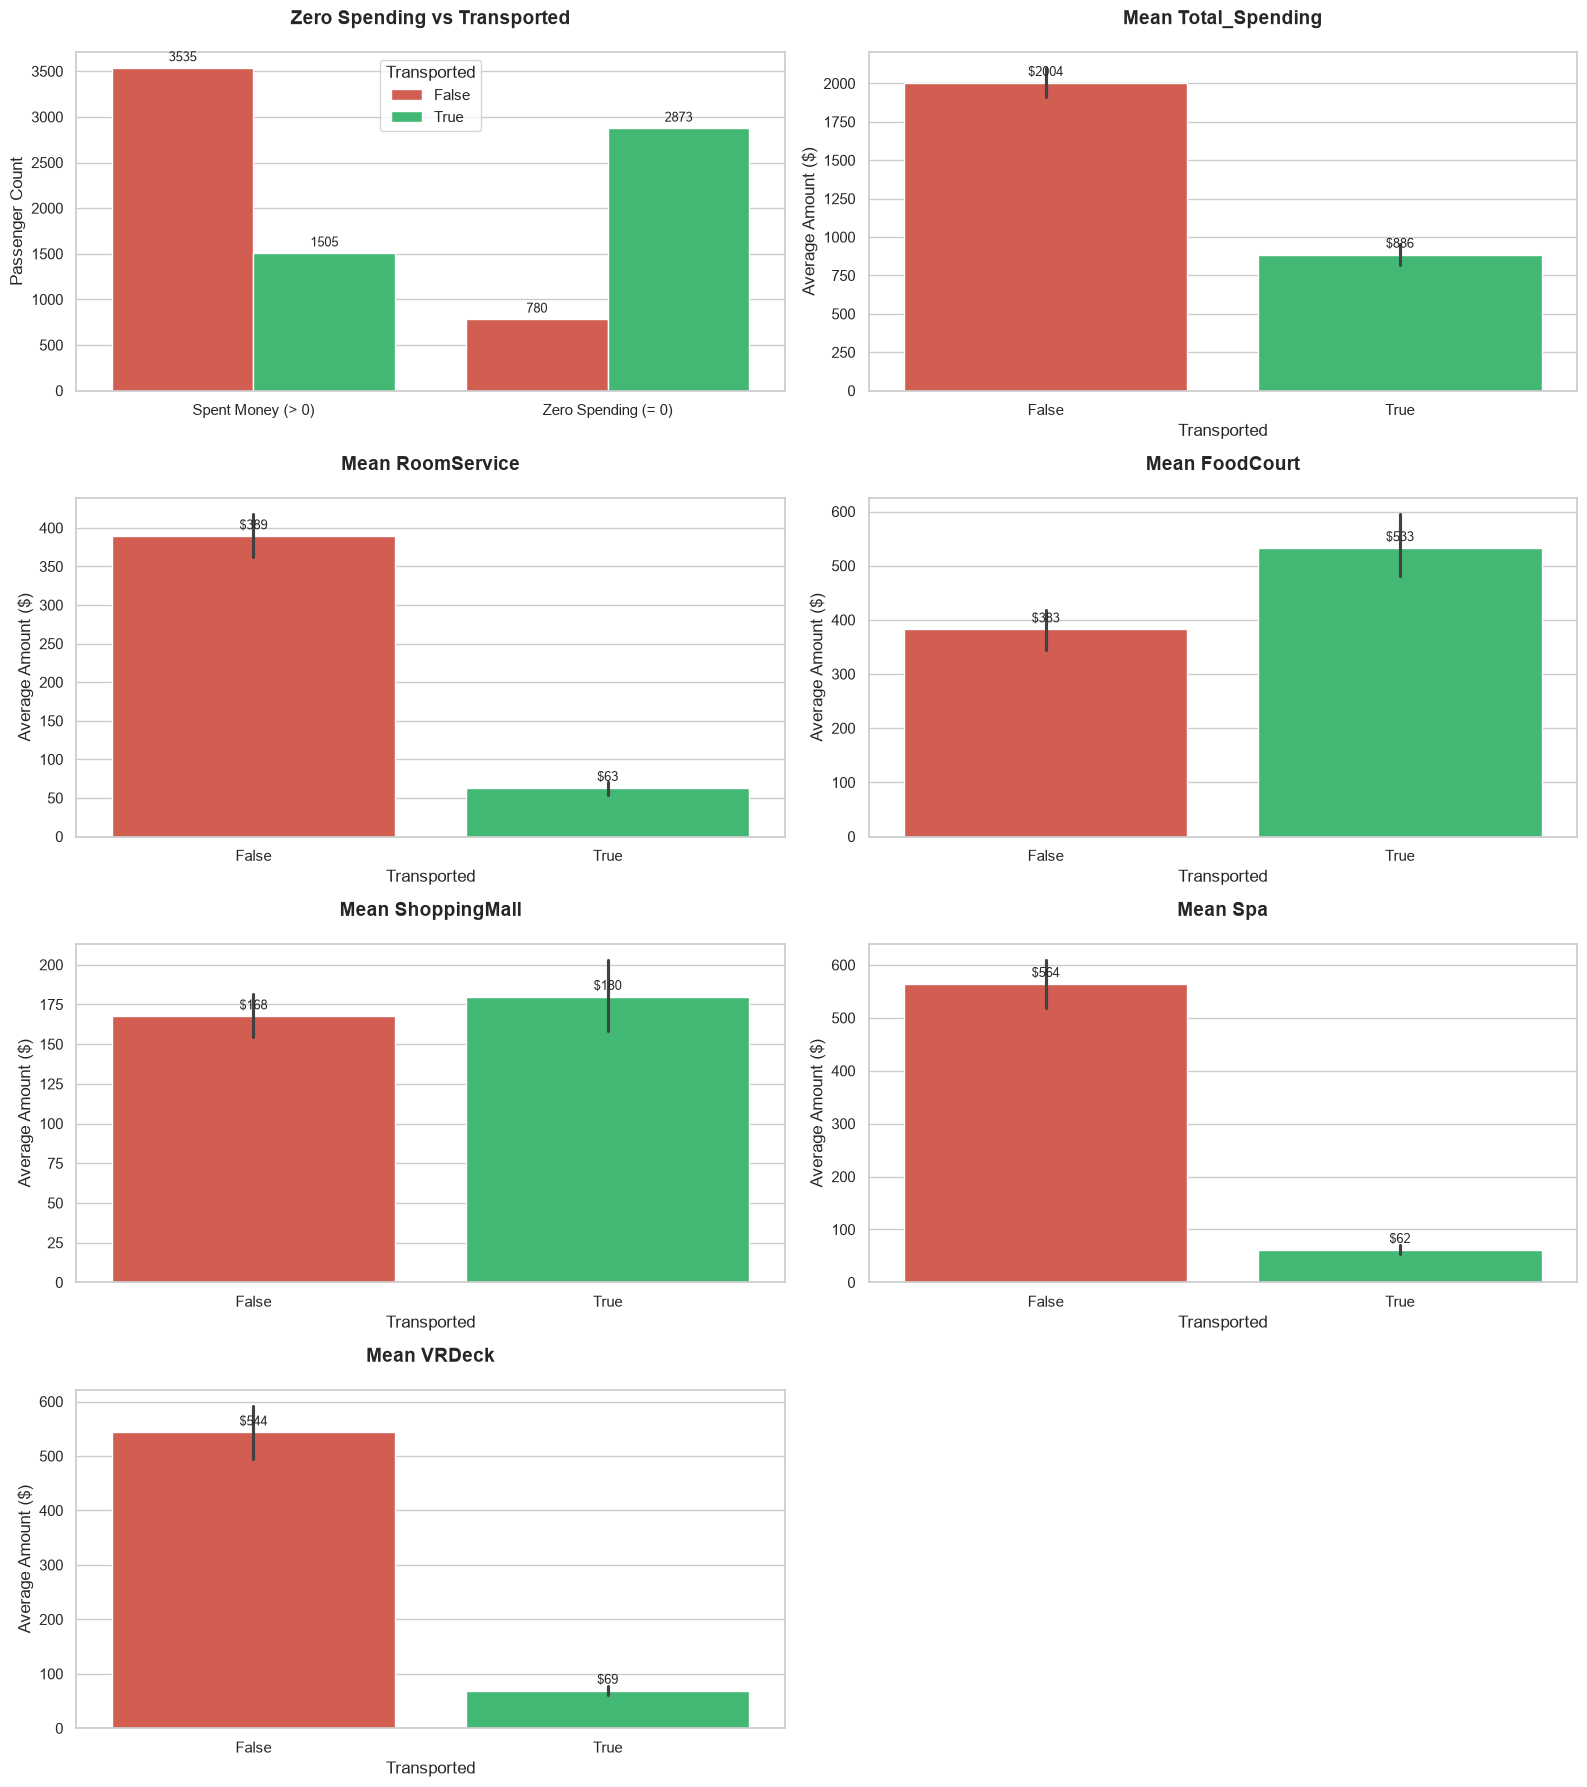

In [5]:
vzr.visualize_spending_vs_target()

### Homeplanet Profile

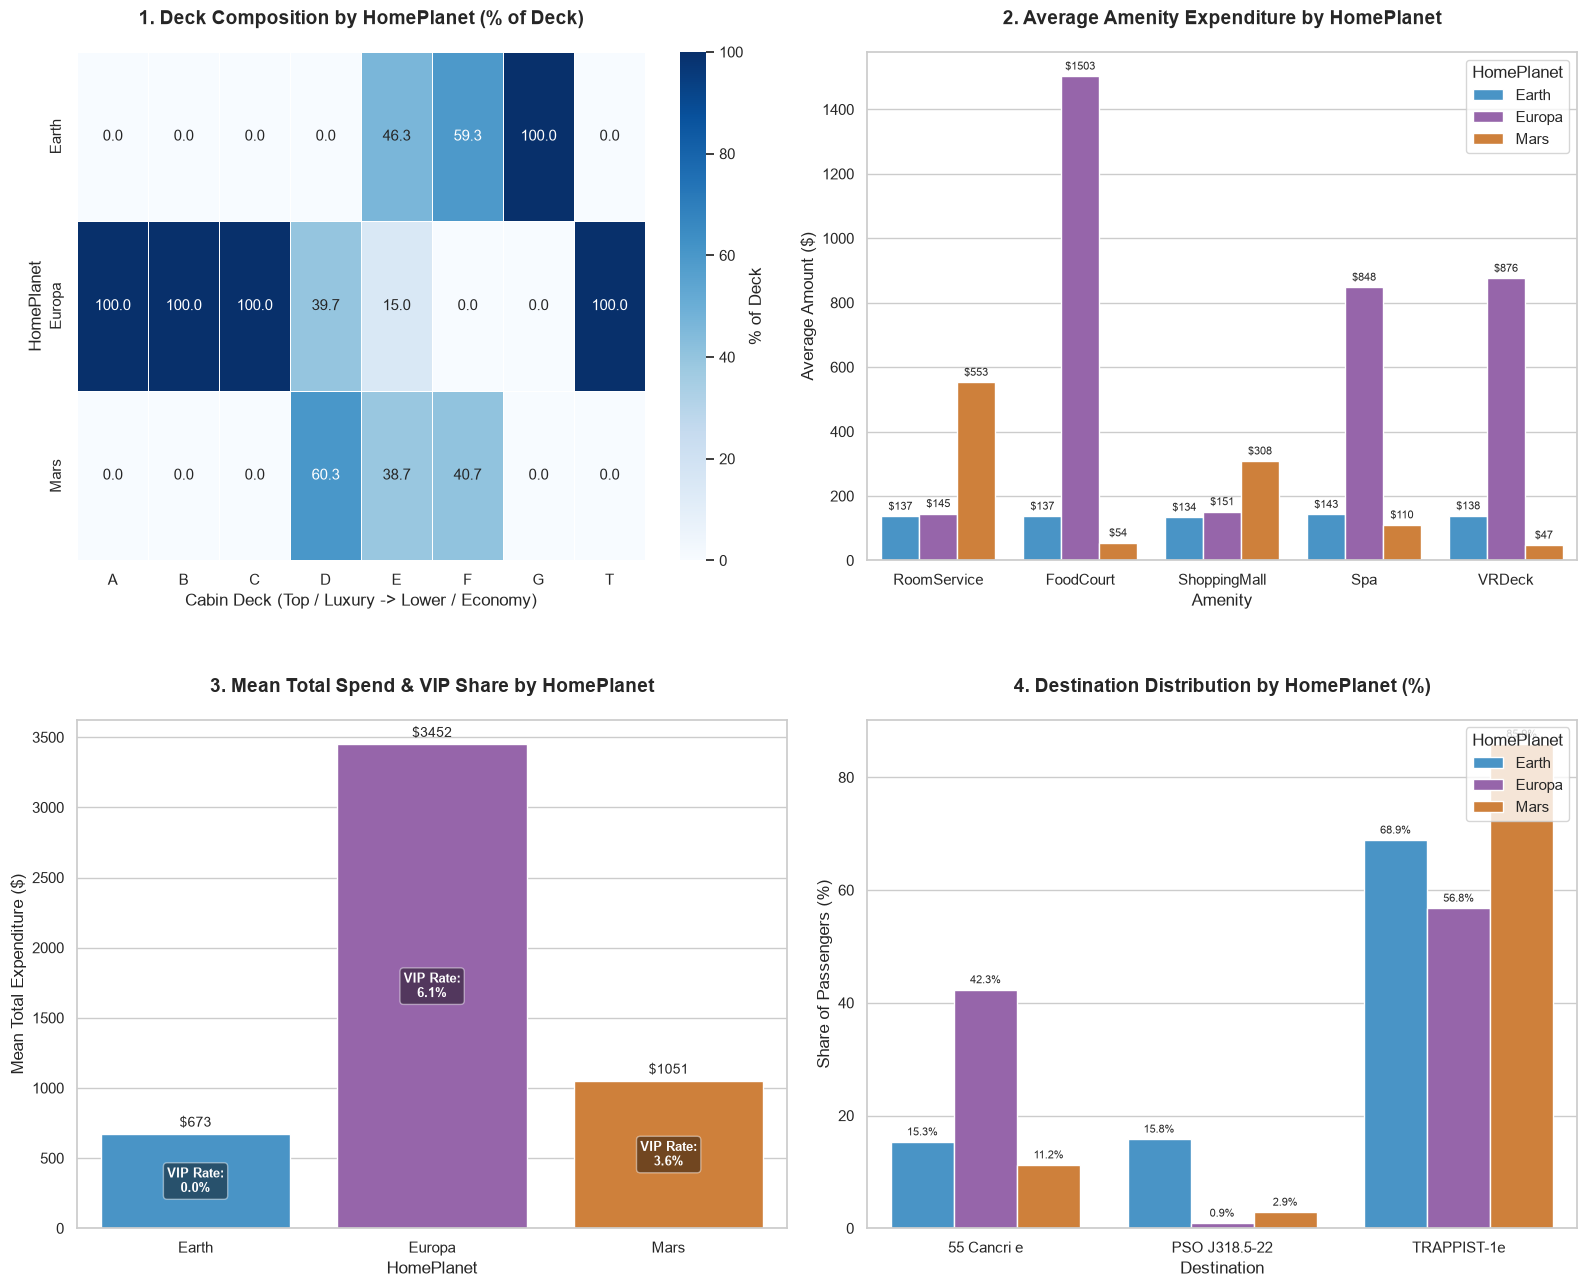

In [5]:
vzr.visualize_homeplanet_profiles()

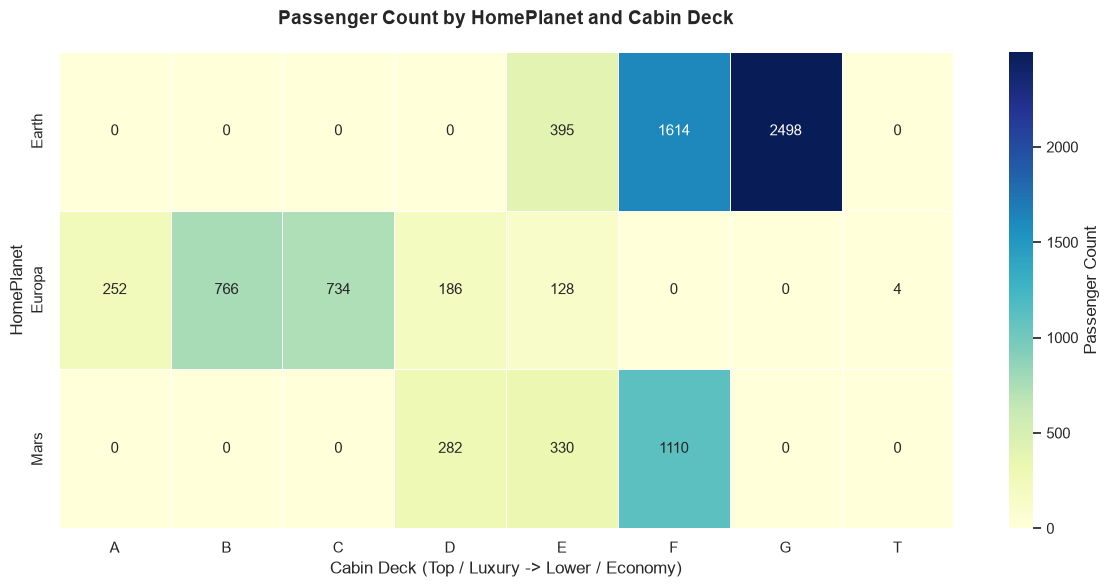

In [ ]:
vzr.visualize_planetary_deck_distribution(normalize = 'count')

### Correlation Heatmap

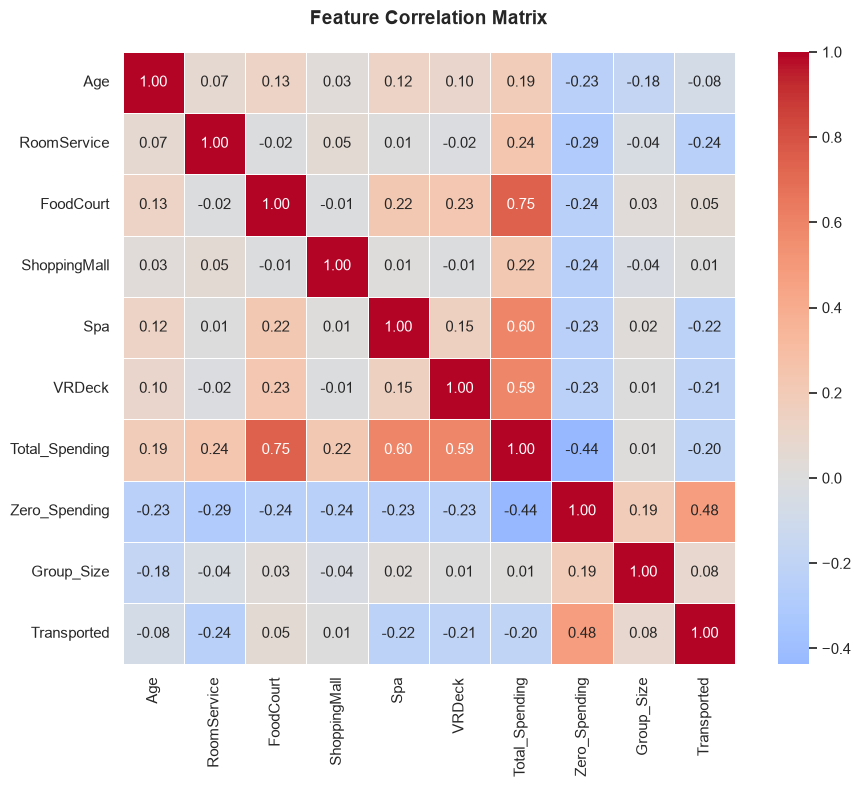

In [6]:
vzr.visualize_correlation_matrix()

### Transported Rate Across Ship Compartments

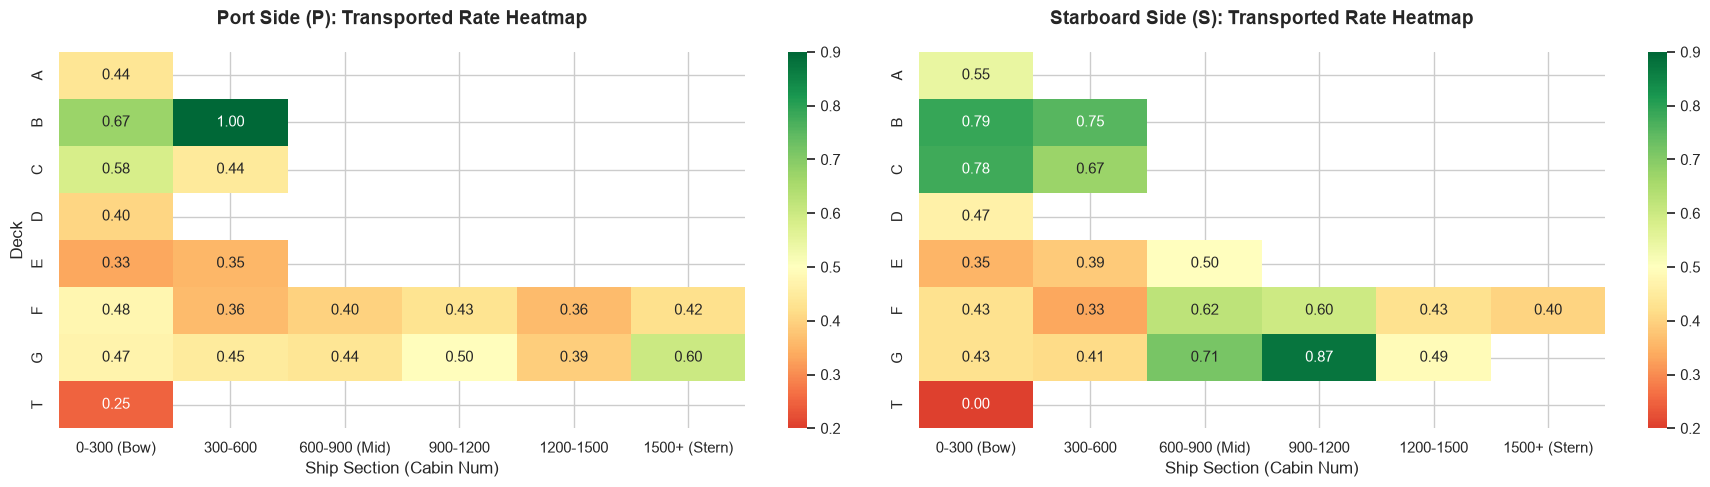

In [5]:
vzr.visualize_cabin_spatial_heatmap()

### Points in 3D space

In [10]:
vzr.visualize_3d_projection(method = 'pca', s = 1.5)

In [11]:
vzr.visualize_3d_projection(method = 'tsne', s = 1.5)

In [5]:
vzr.visualize_3d_projection(method = 'umap', s = 1.5)

## 📊 Key Exploratory Insights & Findings

> **Executive Summary:** Based on statistical, categorical, spatial and dimensionality reduction analysis across the **8,693 training passengers**, teleportation was **not random**. It was primarily determined by **passenger state (CryoSleep confinement)** and the **physical trajectory of the spacetime anomaly** across specific ship compartments (Starboard side, Decks B & C).


### > Target Balance & Data Quality

| Metric | Value | Modeling Implication |
| :--- | :--- | :--- |
| **Target Distribution** | **50.36%** Transported (4,378) vs. **49.64%** Not Transported (4,315) | Near-perfect balance; standard evaluation metrics (Accuracy, ROC-AUC) apply directly without resampling. |
| **Missing Data Rate** | **1.5% – 2.5%** uniformly across feature columns | Missing values appear Missing Completely at Random (MCAR) or Missing at Random (MAR); standard imputation works reliably. |


### > Primary Determinants of Teleportation

#### CryoSleep Status: *The #1 Single Predictor*
* **CryoSleep = True**: **81.76%** transported (3,037 passengers)

* **CryoSleep = False**: **32.89%** transported (5,439 passengers)

* **Impact Delta**: **+48.87%** difference in transport likelihood.

> 🔍 **Physical Narrative:** Passengers inside CryoSleep pods were confined to fixed cabins without situational awareness or mobility. When the spacetime anomaly struck, they had zero opportunity to take shelter or evacuate, making them disproportionately vulnerable.

#### Expenditure Profile: *$0 vs. Active Spenders*
* **Zero Spend (`TotalSpend == 0`)**: **78.65%** transported (3,653 passengers)
* **Active Spenders (`TotalSpend > 0`)**: **29.86%** transported (5,040 passengers)

* **Amenity Breakdown:**
  * **`RoomService`**, **`Spa`**, **`VRDeck`**: Strongly **negatively correlated** with transport (~20–25% transport rate for top spenders). Active patrons in recreation areas were either away from the anomaly's focal zones or alert enough to escape.
  * **`FoodCourt`**, **`ShoppingMall`**: Weaker negative correlation, primarily utilized by high-income Europa travelers.
* **Deterministic Rules:**
  * Passengers in `CryoSleep == True` strictly spend **$0** across all 5 amenities.
  * Children under age 13 almost exclusively have **$0** spend.

### > Spatial & Structural Hull Impact Zones

#### Starboard (S) vs. Port (P) Asymmetry
| Hull Side | Passengers | Transported Rate | Key Observation |
| :---: | :---: | :---: | :--- |
| **Starboard (`S`)** | 4,288 | **55.50%** | Sustained significantly higher impact across nearly every deck. |
| **Port (`P`)** | 4,206 | **45.13%** | Lower transport rate (**+10.37% delta** favoring Starboard). |

<br></br>
> 🧭 **Anomaly Trajectory:** The spacetime anomaly struck or propagated predominantly along the **Starboard flank** of the spaceship.

#### Vertical Deck Vulnerability

* **High-Impact Zones:**
  * **Deck B**: **73.43%** transported (779 passengers)
  * **Deck C**: **68.01%** transported (747 passengers)

* **Moderate Zones:**
  * **Deck G**: **51.62%** transported (2,559 passengers)
  * **Deck A**: **49.61%** transported (256 passengers)

* **Low-Impact / Sheltered Zones:**
  * **Deck F**: **43.99%** transported (2,794 passengers)
  * **Deck D**: **43.31%** transported (478 passengers)
  * **Deck E**: **35.73%** transported (876 passengers)
  * **Deck T**: **20.00%** transported (5 passengers)

* **Longitudinal Gradient (Bow to Stern):**
  * **Decks B & C**: Show consistently high transport rates along the entire length of the deck.
  * **Lower Decks (F & G)**: Forward cabins (Bow, lower cabin numbers) experienced higher transport rates than rear cabins (Stern, higher cabin numbers).


### > Demographics & Passenger Segregation

#### Planetary Origin & Deck Stratification
| HomePlanet | Transport Rate | Typical Decks | Typical Destination | Profile |
| :--- | :---: | :---: | :---: | :--- |
| **Europa** | **65.88%** | Luxury Upper (**A, B, C, T**) | *55 Cancri e* | Wealthiest cohort; high luxury spenders. |
| **Mars** | **52.30%** | Middle / Work (**D, E, F**) | *TRAPPIST-1e* | Moderate spenders (`ShoppingMall`, `RoomService`). |
| **Earth** | **42.39%** | Economy Lower (**E, F, G**) | *TRAPPIST-1e* | Economy cohort; lowest overall transport rate. |

#### Age Dynamics
* **Children (Ages 0–12)**: High transport rate (**~65–80%**). Confined with families in cabin quarters; zero spending.
* **Young Adults (Ages 18–30)**: Lowest transport rate (**~43–46%**). Peak discretionary spenders on `VRDeck`, `Spa`, and `RoomService`.
* **Mature Adults & Seniors (35+)**: Stable baseline (**~48–50%**).

#### VIP Status
* **Non-VIP (`False`)**: **50.63%** transported
* **VIP (`True`)**: **38.19%** transported
* *Explanation:* VIPs are active, older spenders residing on middle-to-high decks with significantly lower CryoSleep rates.


### > Group & Social Network Dynamics

| Group Type | Count | Transported Rate | Pattern |
| :--- | :---: | :---: | :--- |
| **Family / Group (`GroupSize > 1`)** | 3,888 | **56.69%** | Travel groups share or occupy contiguous cabins. |
| **Solo Travelers (`GroupSize == 1`)** | 4,805 | **45.24%** | Lower transport probability (**+11.45% delta** for groups). |

<br></br>

> 👨‍👩‍👧‍👦 **Clustering Effect:** Passengers sharing a `GroupId` (`gggg_xx`) display highly correlated outcomes: an entire family or cabin block was frequently transported or spared as a unit.

<br></br>
---


### Actionable Machine Learning & Feature Engineering Roadmap

| Feature Name | Derivation | Modeling Justification |
| :--- | :--- | :--- |
| **`TotalSpend`** | `RoomService + FoodCourt + ShoppingMall + Spa + VRDeck` | Strong non-linear threshold separating $0 spenders (~79% transport) from active spenders (~30% transport). |
| **`ZeroSpend`** | `TotalSpend == 0` (Boolean flag) | Directly captures the high-transport CryoSleep / child profile. |
| **`Cabin_Deck`** | 1st component of `Cabin` (`deck/num/side`) | Critical vertical vulnerability indicator (Decks B & C: ~70% vs. Deck E: ~36%). |
| **`Cabin_Side`** | 3rd component of `Cabin` (`P` vs. `S`) | Encodes the physical Starboard impact asymmetry (+10.37% delta). |
| **`Cabin_Num`** | 2nd component of `Cabin` (numeric) | Captures the longitudinal gradient along the hull (Bow to Stern). |
| **`Deck_Side`** | Interaction term (e.g., `B_S`, `C_P`) | Isolates localized high-transport hull compartments. |
| **`GroupId`** | Group component of `PassengerId` (`gggg_pp`) | Groups travel together and frequently share identical teleportation outcomes. |
| **`GroupSize`** | Frequency count of `GroupId` | Differentiates solo passengers from families/parties (+11.45% delta for groups). |
| **`Is_Solo`** | `GroupSize == 1` (Boolean flag) | Direct binary split (45.2% solo vs. 56.7% group). |
| **`Age_Group`** | Binned (`[0-4, 5-12, 13-17, 18-30, 31-50, 50+]`) | Captures heightened vulnerability of infants/children and lower transport of young adults. |
